In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('Mall_Customers.csv')

X = dataset.iloc[:, 3:5].values

In [21]:
from sklearn.cluster import AffinityPropagation

# Affinity Propagation model
ap = AffinityPropagation(
    damping=0.9,          # Controls message damping (0.5–1). Higher = more stable, slower convergence
    max_iter=200,         # Maximum number of iterations
    convergence_iter=15,  # Iterations with no change before stopping
    random_state=42)

ap.fit(X)



,damping,0.9
,max_iter,200
,convergence_iter,15
,copy,True
,preference,None
,affinity,'euclidean'
,verbose,False
,random_state,42


In [22]:
cluster_centers = ap.cluster_centers_
cluster_centers

array([[ 25,   5],
       [ 28,  82],
       [ 28,  32],
       [ 47,  52],
       [ 63,  48],
       [ 77,  12],
       [ 78,  90],
       [ 78,  73],
       [103,  85],
       [103,  23]])

In [13]:
supervised = pd.DataFrame(dataset)

supervised['Cluster group'] = ap.labels_

supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster group
0,1,Male,19,15,39,2
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,8
196,197,Female,45,126,28,9
197,198,Male,32,126,74,8
198,199,Male,32,137,18,9


C:\Users\z030703\AppData\Local\anaconda3\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


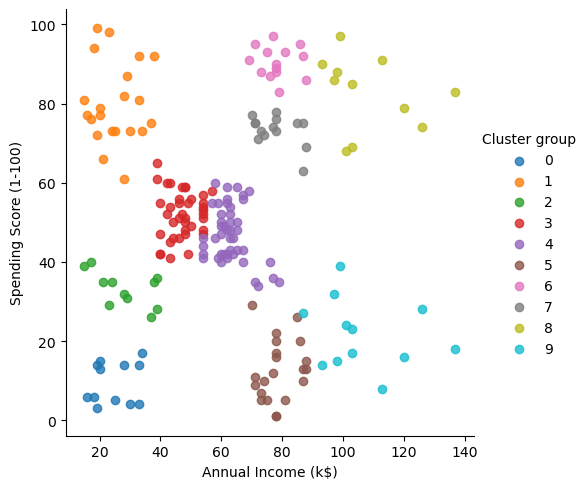

In [14]:
#visualizing the clustered data
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True, legend_out=True)